#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Titanic

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=blue> 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde
import numpy as np
import requests


## <font color=blue> 2. Carregamento e Preparação do Dataset

In [2]:
# constantes pra usar nos graficos
CORES_CLASSE = {1: "gold", 2: "steelblue", 3: "tomato"}
LABELS_CLASSE = {1: "1ª Classe", 2: "2ª Classe", 3: "3ª Classe"}
CORES_RESULTADO = {"Sobreviveu": "seagreen", "Não Sobreviveu": "tomato"}

PATH_TITANIC = "/home/heitor/Documentos/projetos/MBA/01_estatistica/01_estatistica-titanic/titanic.csv"
PATH_BOE = "/home/heitor/Documentos/projetos/MBA/01_estatistica/99_extras/titanic/a-millennium-of-macroeconomic-data-for-the-uk.xlsx"
PATH_TITANIC_ENRIQUECIDO = "/home/heitor/Documentos/projetos/MBA/01_estatistica/99_extras/titanic/titanic_enriquecido.csv"


### 2.1 Carregamento do dataset

**observações:**
- dataset original: 887 passageiros. passageiros com `Fare = 0` removidos (tripulação ou embarque gratuito)
- dataset de análise: passageiros pagantes com variáveis numéricas e categóricas disponíveis

In [3]:
titanic_df = pd.read_csv(PATH_TITANIC)
titanic_df.columns = titanic_df.columns.str.strip()
titanic_df = titanic_df[titanic_df["Fare"] > 0].reset_index(drop=True)

print(f"titanic_df: {titanic_df.shape}")
titanic_df.info()

titanic_df: (872, 8)
<class 'pandas.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 872 non-null    int64  
 1   Pclass                   872 non-null    int64  
 2   Name                     872 non-null    str    
 3   Sex                      872 non-null    str    
 4   Age                      872 non-null    float64
 5   Siblings/Spouses Aboard  872 non-null    int64  
 6   Parents/Children Aboard  872 non-null    int64  
 7   Fare                     872 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 54.6 KB


### 2.2 Feature Engineering

- **AgeGroup**: fiz faixas etárias para melhorar a análise (criança: 0-12, jovem: 13-17, adulto: 18-59, idoso: 60+)

In [4]:
bins = [0, 12, 17, 59, 100]
labels = ["Criança", "Jovem", "Adulto", "Idoso"]
titanic_df["AgeGroup"] = pd.cut(titanic_df["Age"], bins=bins, labels=labels, right=True)

print("Distribuição por AgeGroup:")
print(titanic_df["AgeGroup"].value_counts().sort_index())

Distribuição por AgeGroup:
AgeGroup
Criança     79
Jovem       51
Adulto     711
Idoso       31
Name: count, dtype: int64


### 2.3 Correção inflacionária (BoE + World Bank)

Adicionei dados externos para uma análise mais rica. Houve questionamento na aula sobre valores relativos e valores absolutos. no caso deste dataset, é impossível trabalhar com valores absolutos por conta do lapso temporal de mais de um século. o valor não tem o mesmo valor. e para termos noção de grandeza, houve o tratamento da coluna fare com a inflação corrigida de acordo com o índice do **Bank of England** e **World Bank** 

**Bank of England** — *A Millennium of Macroeconomic Data for the UK* (v3.1), aba A47, coluna H. Índice composto de preços do Reino Unido normalizado para 100 em 2016. Cobre 1912 → 2016.



In [5]:
boe = pd.read_excel(
    PATH_BOE,
    sheet_name="A47. Wages and prices",
    header=6,
    usecols=[0, 7],
)
boe.columns = ["year", "price_index"]
boe = boe.dropna(subset=["year", "price_index"])
boe["year"] = boe["year"].astype(int)

idx_1912 = boe.loc[boe["year"] == 1912, "price_index"].values[0]
idx_2016 = boe.loc[boe["year"] == 2016, "price_index"].values[0]
fator_boe = idx_2016 / idx_1912

# endpoint: https://api.worldbank.org/v2/country/{país}/indicator/{indicador}
# indicador FP.CPI.TOTL 

resp = requests.get(
    "https://api.worldbank.org/v2/country/GBR/indicator/FP.CPI.TOTL",
    params={"format": "json", "date": "2016:2024", "per_page": 20},
    timeout=10,
)
wb_data = pd.DataFrame(resp.json()[1])[["date", "value"]].dropna()
wb_data["date"] = wb_data["date"].astype(int)

cpi_2016 = wb_data.loc[wb_data["date"] == 2016, "value"].values[0]
cpi_2024 = wb_data.loc[wb_data["date"] == 2024, "value"].values[0]
fator_wb = cpi_2024 / cpi_2016

FATOR_INFLACAO = fator_boe * fator_wb

titanic_df["Fare_2024"] = titanic_df["Fare"] * FATOR_INFLACAO

print(f"BoE — índice 1912: {idx_1912:.4f} | índice 2016: {idx_2016:.4f} | fator: {fator_boe:.2f}×")
print(f"World Bank — CPI 2016: {cpi_2016:.2f} | CPI 2024: {cpi_2024:.2f} | fator: {fator_wb:.4f}×")
print(f"Fator total 1912→2024: {FATOR_INFLACAO:.2f}×")
print(f"Exemplo — £7 (3ª classe típica) → £ {7 * FATOR_INFLACAO:,.0f} em 2024")
print(f"Exemplo — £512 (1ª classe topo) → £ {512 * FATOR_INFLACAO:,.0f} em 2024")

BoE — índice 1912: 1.1753 | índice 2016: 100.0000 | fator: 85.09×
World Bank — CPI 2016: 112.08 | CPI 2024: 147.41 | fator: 1.3153×
Fator total 1912→2024: 111.91×
Exemplo — £7 (3ª classe típica) → £ 783 em 2024
Exemplo — £512 (1ª classe topo) → £ 57,298 em 2024


### 2.4 Visão geral do dataset

In [6]:
titanic_df.info()
titanic_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Survived                 872 non-null    int64   
 1   Pclass                   872 non-null    int64   
 2   Name                     872 non-null    str     
 3   Sex                      872 non-null    str     
 4   Age                      872 non-null    float64 
 5   Siblings/Spouses Aboard  872 non-null    int64   
 6   Parents/Children Aboard  872 non-null    int64   
 7   Fare                     872 non-null    float64 
 8   AgeGroup                 872 non-null    category
 9   Fare_2024                872 non-null    float64 
dtypes: category(1), float64(3), int64(4), str(2)
memory usage: 62.5 KB


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,AgeGroup,Fare_2024
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,Adulto,811.350600
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,Adulto,7977.344584
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,Adulto,886.890139
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,Adulto,5942.443706
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,Adulto,900.878942
5,0,3,Mr. James Moran,male,27.0,0,0,8.4583,Adulto,946.571970
6,0,1,Mr. Timothy J McCarthy,male,54.0,0,0,51.8625,Adulto,5803.954551
7,0,3,Master. Gosta Leonard Palsson,male,2.0,3,1,21.0750,Criança,2358.512262
8,1,3,Mrs. Oscar W (Elisabeth Vilhelmina Berg) Johnson,female,27.0,0,2,11.1333,Adulto,1245.932364
9,1,2,Mrs. Nicholas (Adele Achem) Nasser,female,14.0,1,0,30.0708,Jovem,3365.236086


In [ ]:

#titanic_df.to_csv(PATH_TITANIC_ENRIQUECIDO, index=False)
print(f"Dataset salvo: {PATH_TITANIC_ENRIQUECIDO}")
print(f"Shape: {titanic_df.shape} | Colunas: {list(titanic_df.columns)}")

Dataset salvo: /home/heitor/Documentos/projetos/MBA/01_estatistica/99_extras/titanic/titanic_enriquecido.csv
Shape: (872, 10) | Colunas: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare', 'AgeGroup', 'Fare_2024']


## <font color=blue> 3. Análise Exploratória dos Dados

### 3.0 Identificação das Variáveis

Tabela com detalhes que o professor pediu de detalhar as variáveis qualitativas e quantitativas

In [ ]:
variaveis = pd.DataFrame(
    [
        {
            "Variável": "Survived",
            "Tipo": "Qualitativa",
            "Subtipo (se Quantitativa)": "—",
            "Valores Possíveis (se Qualitativa)": "0 = Não Sobreviveu / 1 = Sobreviveu",
        },
        {
            "Variável": "Pclass",
            "Tipo": "Qualitativa",
            "Subtipo (se Quantitativa)": "—",
            "Valores Possíveis (se Qualitativa)": "1ª Classe / 2ª Classe / 3ª Classe",
        },
        {
            "Variável": "Name",
            "Tipo": "Qualitativa",
            "Subtipo (se Quantitativa)": "—",
            "Valores Possíveis (se Qualitativa)": "Nome do passageiro (texto livre)",
        },
        {
            "Variável": "Sex",
            "Tipo": "Qualitativa",
            "Subtipo (se Quantitativa)": "—",
            "Valores Possíveis (se Qualitativa)": "male / female",
        },
        {
            "Variável": "Age",
            "Tipo": "Quantitativa",
            "Subtipo (se Quantitativa)": "Contínua",
            "Valores Possíveis (se Qualitativa)": "—",
        },
        {
            "Variável": "Siblings/Spouses Aboard",
            "Tipo": "Quantitativa",
            "Subtipo (se Quantitativa)": "Discreta",
            "Valores Possíveis (se Qualitativa)": "—",
        },
        {
            "Variável": "Parents/Children Aboard",
            "Tipo": "Quantitativa",
            "Subtipo (se Quantitativa)": "Discreta",
            "Valores Possíveis (se Qualitativa)": "—",
        },
        {
            "Variável": "Fare",
            "Tipo": "Quantitativa",
            "Subtipo (se Quantitativa)": "Contínua",
            "Valores Possíveis (se Qualitativa)": "—",
        },
    ]
)

display(
    variaveis.style.set_caption(
        "Tabela 3.0 — Identificação das Variáveis do Dataset Titanic (D1)"
    )
    .set_properties(**{"text-align": "left"})
    .hide(axis="index")
)

Variável,Tipo,Subtipo (se Quantitativa),Valores Possíveis (se Qualitativa)
Survived,Qualitativa,—,0 = Não Sobreviveu / 1 = Sobreviveu
Pclass,Qualitativa,—,1ª Classe / 2ª Classe / 3ª Classe
Name,Qualitativa,—,Nome do passageiro (texto livre)
Sex,Qualitativa,—,male / female
Age,Quantitativa,Contínua,—
Siblings/Spouses Aboard,Quantitativa,Discreta,—
Parents/Children Aboard,Quantitativa,Discreta,—
Fare,Quantitativa,Contínua,—


### 3.1 Distribuição da Tarifa

**observações:**
- passageiros com `Fare = 0` já foram excluídos no carregamento do dataset

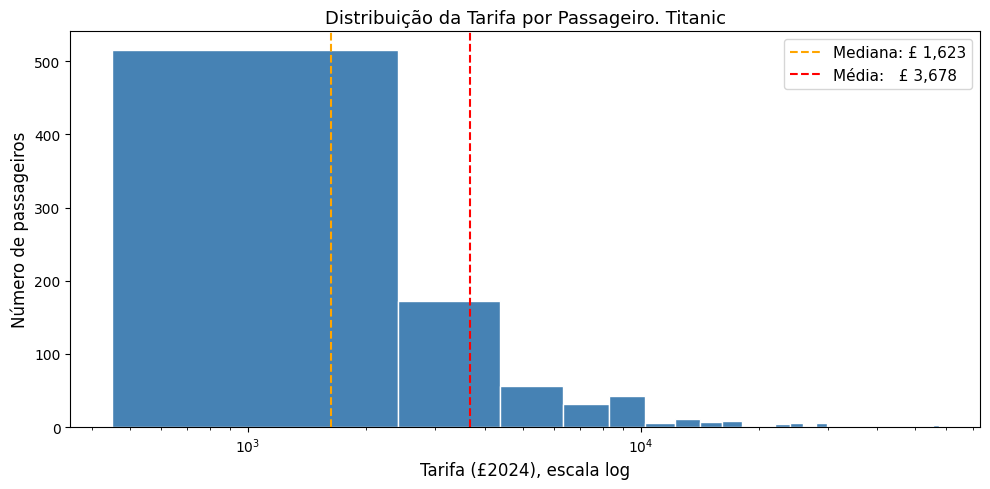

In [9]:
tarifas = titanic_df["Fare_2024"]
n_bins = np.sqrt(len(titanic_df)).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tarifas, bins=n_bins, edgecolor="white", color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Tarifa (£2024), escala log", fontsize=12)
ax.set_ylabel("Número de passageiros", fontsize=12)
ax.set_title("Distribuição da Tarifa por Passageiro. Titanic", fontsize=13)
ax.axvline(
    tarifas.median(),
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Mediana: £ {tarifas.median():,.0f}",
)
ax.axvline(
    tarifas.mean(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Média:   £ {tarifas.mean():,.0f}",
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**observações:**
- distribuição assimétrica à direita
- mediana: £ 1.623. média: £ 3.678. razão de ~2.3x
- concentração de tarifas elevadas em poucos passageiros

#### 3.1.2 Distribuição da Tarifa por Classe. Densidade

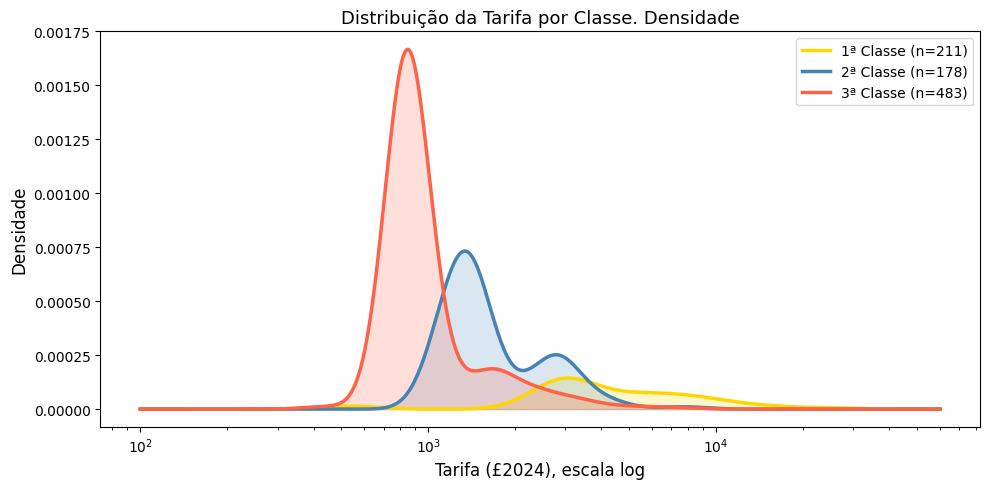

In [10]:
x_range = np.logspace(np.log10(100), np.log10(60000), 500)

fig, ax = plt.subplots(figsize=(10, 5))
for classe, cor in CORES_CLASSE.items():
    dados_classe = titanic_df[titanic_df["Pclass"] == classe]["Fare_2024"]
    kde = gaussian_kde(np.log(dados_classe))
    densidade = kde(np.log(x_range)) / x_range
    ax.plot(
        x_range,
        densidade,
        color=cor,
        linewidth=2.5,
        label=f"{LABELS_CLASSE[classe]} (n={len(dados_classe)})",
    )
    ax.fill_between(x_range, densidade, alpha=0.2, color=cor)

ax.set_xscale("log")
ax.set_xlabel("Tarifa (£2024), escala log", fontsize=12)
ax.set_ylabel("Densidade", fontsize=12)
ax.set_title("Distribuição da Tarifa por Classe. Densidade", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**observações:**
- 3a classe: pico próximo a £ 900. passageiros concentrados entre £ 600 e £ 3.400
- 2a classe: dois picos em torno de £ 1.500 e £ 3.000. dois subgrupos com precificações distintas
- 1a classe: distribuição longa com tarifas que chegam a £ 57.000. alta variabilidade interna

#### 3.1.3 Medidas Descritivas da Tarifa

Histograma em escala logarítmica com as principais medidas de posição e dispersão sobrepostas: média, mediana e moda como linhas verticais; banda sombreada para média ± desvio padrão; anotações de mínimo e máximo nas extremidades.

### 3.2 Distribuição por Classe

#### 3.2.1 Total de passageiros por classe

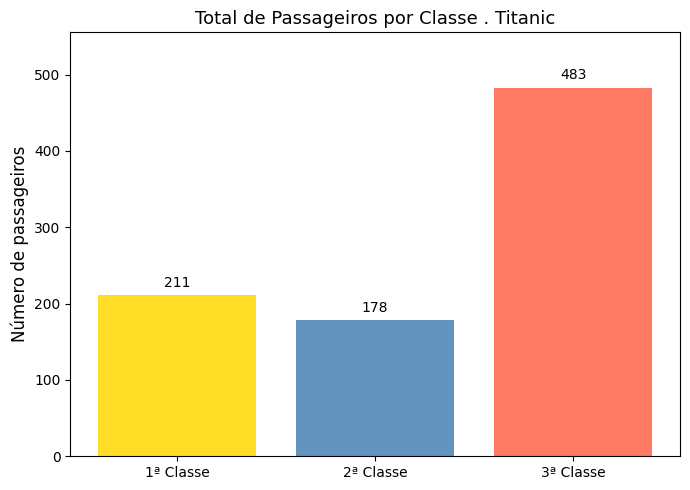

In [11]:
passageiros_classe = titanic_df["Pclass"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [LABELS_CLASSE[p] for p in passageiros_classe.index],
    passageiros_classe.values,
    color=[CORES_CLASSE[p] for p in passageiros_classe.index],
    alpha=0.85,
)
ax.set_ylabel("Número de passageiros", fontsize=12)
ax.set_title("Total de Passageiros por Classe . Titanic", fontsize=13)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=10)
ax.set_ylim(0, passageiros_classe.max() * 1.15)
plt.tight_layout()
plt.show()

**observações:**
- 3a classe: 483 passageiros (55.4%)
- 1a classe: 211 passageiros (24.2%)
- 2a classe: 178 passageiros (20.4%)

#### 3.2.2 Taxa de sobrevivência por classe

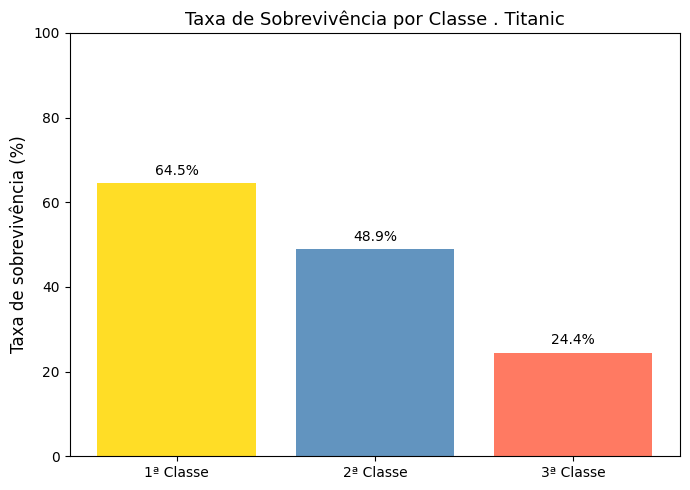

In [12]:
sobrevivencia_classe = (
    titanic_df.groupby("Pclass")["Survived"].mean().sort_index() * 100
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [LABELS_CLASSE[p] for p in sobrevivencia_classe.index],
    sobrevivencia_classe.values,
    color=[CORES_CLASSE[p] for p in sobrevivencia_classe.index],
    alpha=0.85,
)
ax.set_ylabel("Taxa de sobrevivência (%)", fontsize=12)
ax.set_title("Taxa de Sobrevivência por Classe . Titanic", fontsize=13)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

**observações:**
- 1a classe: 64.5% de taxa de sobrevivência
- 2a classe: 48.9% de taxa de sobrevivência
- 3a classe: 24.4% de taxa de sobrevivência
- diferença entre 1a e 3a classe: 40.0 pontos percentuais

#### 3.2.3 Distribuição de Sobrevivência

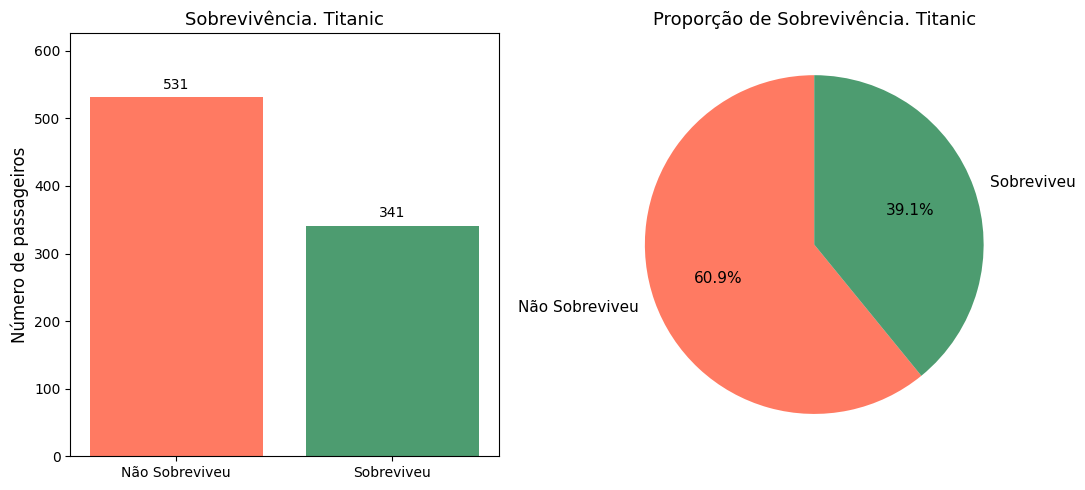

In [13]:
contagem_survived = titanic_df["Survived"].value_counts().sort_index()
labels_survived = {0: "Não Sobreviveu", 1: "Sobreviveu"}
cores_surv = [CORES_RESULTADO[labels_survived[k]] for k in contagem_survived.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# gráfico de barras
bars = ax1.bar(
    [labels_survived[k] for k in contagem_survived.index],
    contagem_survived.values,
    color=cores_surv,
    alpha=0.85,
)
ax1.set_ylabel("Número de passageiros", fontsize=12)
ax1.set_title("Sobrevivência. Titanic", fontsize=13)
ax1.bar_label(bars, fmt="%d", padding=4, fontsize=10)
ax1.set_ylim(0, contagem_survived.max() * 1.18)

# gráfico de pizza
ax2.pie(
    contagem_survived.values,
    labels=[labels_survived[k] for k in contagem_survived.index],
    colors=cores_surv,
    autopct="%.1f%%",
    startangle=90,
    wedgeprops=dict(alpha=0.85),
    textprops=dict(fontsize=11),
)
ax2.set_title("Proporção de Sobrevivência. Titanic", fontsize=13)

plt.tight_layout()
plt.show()

**observações:**
- 531 passageiros não sobreviveram (60.9%) e 341 sobreviveram (39.1%) — mais de 6 em cada 10 não sobreviveram
- o gráfico de pizza evidencia a proporção diretamente; o de barras permite comparar os volumes absolutos
- variável nominal: a moda é "Não Sobreviveu"; medidas de tendência central não se aplicam

### 3.3 Sobrevivência por Variáveis Qualitativas

Para cada variável qualitativa (Sexo, Classe e Faixa Etária), apresento três tipos de visualização:

1. **Representatividade**: gráfico de barras comparando a proporção de passageiros de cada categoria com a proporção de sobreviventes que essa categoria representa. Permite identificar se algum grupo sobreviveu proporcionalmente mais do que sua presença numérica.

2. **Distribuição da tarifa**: box plot em escala logarítmica mostrando a dispersão das tarifas dentro de cada categoria. Excluo passageiros com `Fare = 0` para focar na distribuição real.

3. **Resultado por categoria**: dois gráficos lado a lado. (a) barras empilhadas com a taxa de sobrevivência e não sobrevivência por categoria. e (b) barras agrupadas com a tarifa média de sobreviventes e não sobreviventes por categoria.

#### 3.3.0 Funções genéricas de plot

In [14]:
def plot_representatividade(df, coluna, titulo, ax, order=None, label_map=None):
    total_pass = df[coluna].value_counts(normalize=True) * 100
    total_surv = df[df["Survived"] == 1][coluna].value_counts(normalize=True) * 100
    categorias = order if order is not None else total_pass.index.tolist()
    labels = [
        label_map[c] if label_map and c in label_map else str(c) for c in categorias
    ]
    x = range(len(categorias))
    w = 0.35
    bars1 = ax.bar(
        [i - w / 2 for i in x],
        [total_pass.get(c, 0) for c in categorias],
        width=w,
        label="% de passageiros",
        color=CORES_RESULTADO["Não Sobreviveu"],
        alpha=0.8,
    )
    bars2 = ax.bar(
        [i + w / 2 for i in x],
        [total_surv.get(c, 0) for c in categorias],
        width=w,
        label="% dos sobreviventes",
        color=CORES_RESULTADO["Sobreviveu"],
        alpha=0.8,
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=0, ha="center")
    ax.set_ylabel("Percentual (%)")
    ax.set_title(titulo)
    ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=8)
    ax.legend()


def plot_boxplot_tarifa(
    df,
    coluna,
    categorias,
    titulo,
    cor="steelblue",
    cores=None,
    figsize=(10, 5),
    labels=None,
):
    dados = [df[df[coluna] == c]["Fare_2024"].dropna() for c in categorias]
    labels = labels or [str(x) for x in categorias]
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(
        dados,
        tick_labels=labels,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(cores[i] if cores else cor)
        patch.set_alpha(0.6)
    ax.set_yscale("log")
    ax.set_ylabel("Tarifa (£2024), escala log", fontsize=12)
    ax.set_title(f"Distribuição da Tarifa por {titulo}. Titanic", fontsize=13)
    plt.xticks(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()
    for label, d in zip(labels, dados):
        print(f"{label}: mediana = £ {d.median():,.0f} | n = {len(d)}")


def plot_sobrevivencia_por_variavel(
    df, coluna, categorias, titulo, figsize=(13, 5), label_map=None
):
    df = df.copy()
    df["Resultado"] = df["Survived"].map({1: "Sobreviveu", 0: "Não Sobreviveu"})
    labels = [
        label_map[c] if label_map and c in label_map else str(c) for c in categorias
    ]

    proporcoes = (
        df.groupby([coluna, "Resultado"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Sobreviveu", "Não Sobreviveu"], fill_value=0)
    )
    proporcoes = proporcoes.div(proporcoes.sum(axis=1), axis=0) * 100
    proporcoes = proporcoes.reindex(categorias)

    tarifa_media = (
        df.groupby([coluna, "Resultado"])["Fare_2024"]
        .mean()
        .unstack(fill_value=0)
        .reindex(columns=["Sobreviveu", "Não Sobreviveu"], fill_value=0)
        .reindex(categorias)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    bottom = [0] * len(categorias)
    for resultado in ["Sobreviveu", "Não Sobreviveu"]:
        vals = proporcoes[resultado].tolist()
        ax1.bar(
            range(len(categorias)),
            vals,
            bottom=bottom,
            label=resultado,
            color=CORES_RESULTADO[resultado],
            alpha=0.8,
        )
        bottom = [b + v for b, v in zip(bottom, vals)]
    ax1.set_xticks(range(len(categorias)))
    ax1.set_xticklabels(labels, rotation=0, ha="center", fontsize=9)
    ax1.set_ylabel("% de passageiros")
    ax1.set_title(f"Taxa de sobrevivência por {titulo}")
    ax1.legend(loc="upper right", fontsize=8)

    x = range(len(categorias))
    w = 0.35
    for i, resultado in enumerate(["Sobreviveu", "Não Sobreviveu"]):
        vals = tarifa_media[resultado].tolist()
        ax2.bar(
            [xi + (i - 0.5) * w for xi in x],
            vals,
            width=w,
            label=resultado,
            color=CORES_RESULTADO[resultado],
            alpha=0.8,
        )
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(labels, rotation=0, ha="center", fontsize=9)
    ax2.set_ylabel("Tarifa média (£2024)")
    ax2.set_title(f"Tarifa média por resultado. {titulo}")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

#### 3.3.1 Sexo

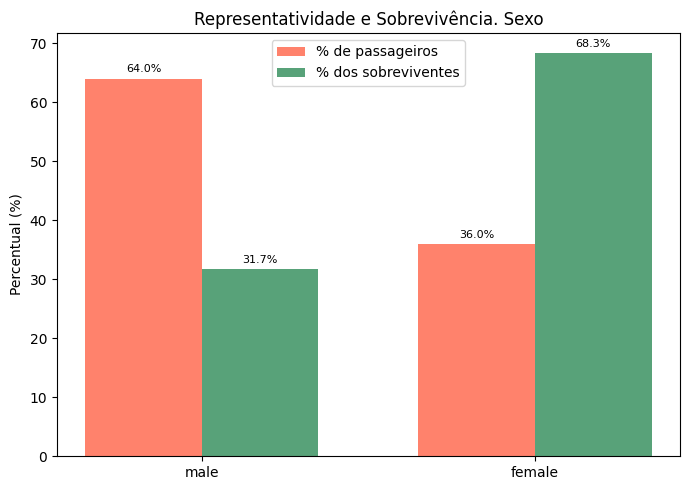

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_representatividade(
    titanic_df, "Sex", "Representatividade e Sobrevivência. Sexo", ax
)
plt.tight_layout()
plt.show()

##### Distribuição da Tarifa por Sexo

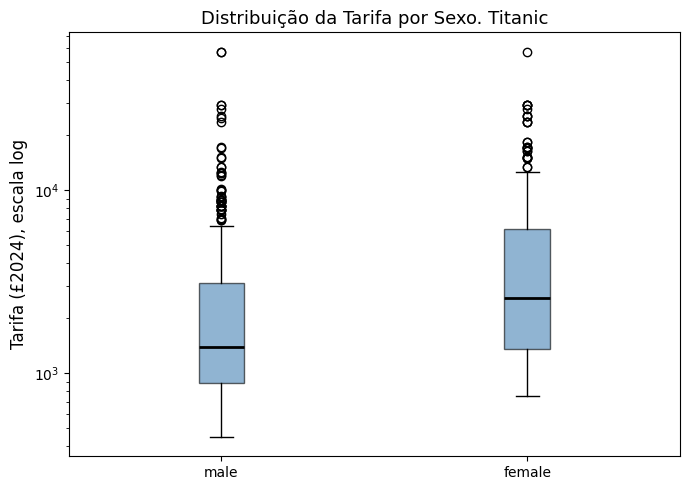

male: mediana = £ 1,389 | n = 558
female: mediana = £ 2,574 | n = 314


In [36]:
plot_boxplot_tarifa(
    titanic_df, "Sex", categorias=["male", "female"], titulo="Sexo", figsize=(7, 5)
)

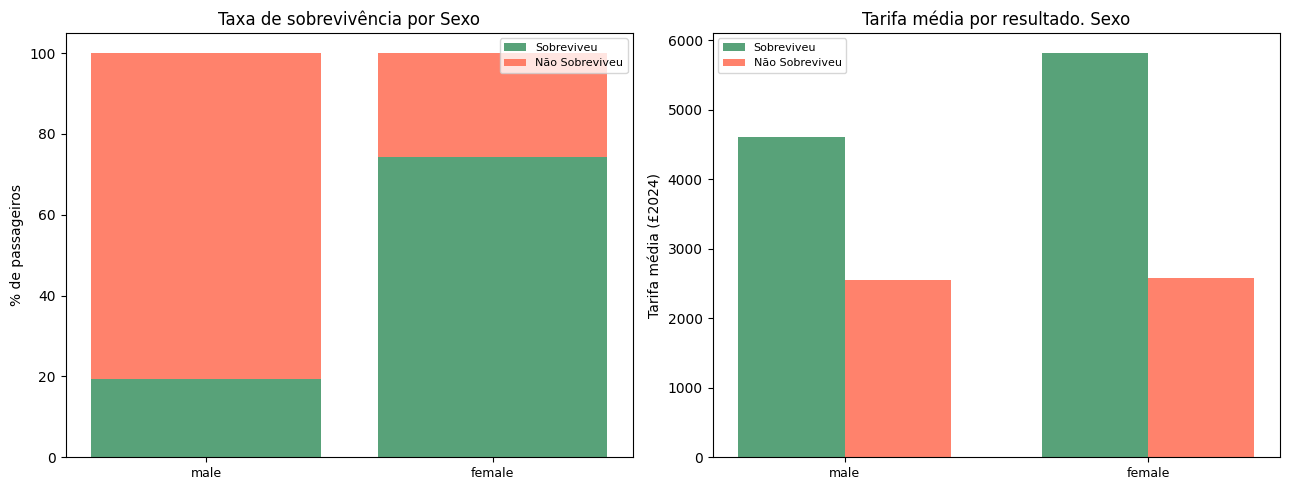

In [17]:
plot_sobrevivencia_por_variavel(
    titanic_df, "Sex", categorias=["male", "female"], titulo="Sexo"
)

**observações:**
- mulheres: 74.2% de taxa de sobrevivência (314 passageiras)
- homens: 19.4% de taxa de sobrevivência (558 passageiros)
- diferença de 54.8 pontos percentuais

#### 3.3.2 Classe

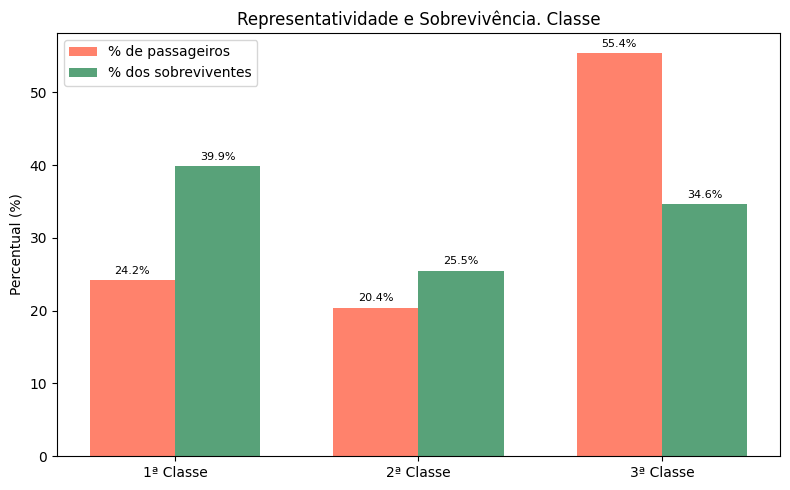

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_representatividade(
    titanic_df,
    "Pclass",
    "Representatividade e Sobrevivência. Classe",
    ax,
    order=[1, 2, 3],
    label_map=LABELS_CLASSE,
)
plt.tight_layout()
plt.show()

##### Distribuição da Tarifa por Classe

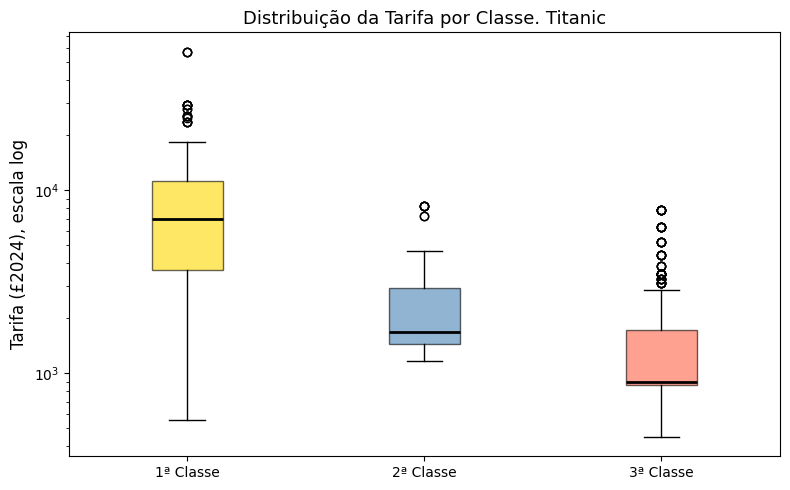

1ª Classe: mediana = £ 6,936 | n = 211
2ª Classe: mediana = £ 1,681 | n = 178
3ª Classe: mediana = £ 901 | n = 483


In [19]:
plot_boxplot_tarifa(
    titanic_df,
    "Pclass",
    categorias=[1, 2, 3],
    labels=[LABELS_CLASSE[c] for c in [1, 2, 3]],
    cores=[CORES_CLASSE[c] for c in [1, 2, 3]],
    titulo="Classe",
    figsize=(8, 5),
)

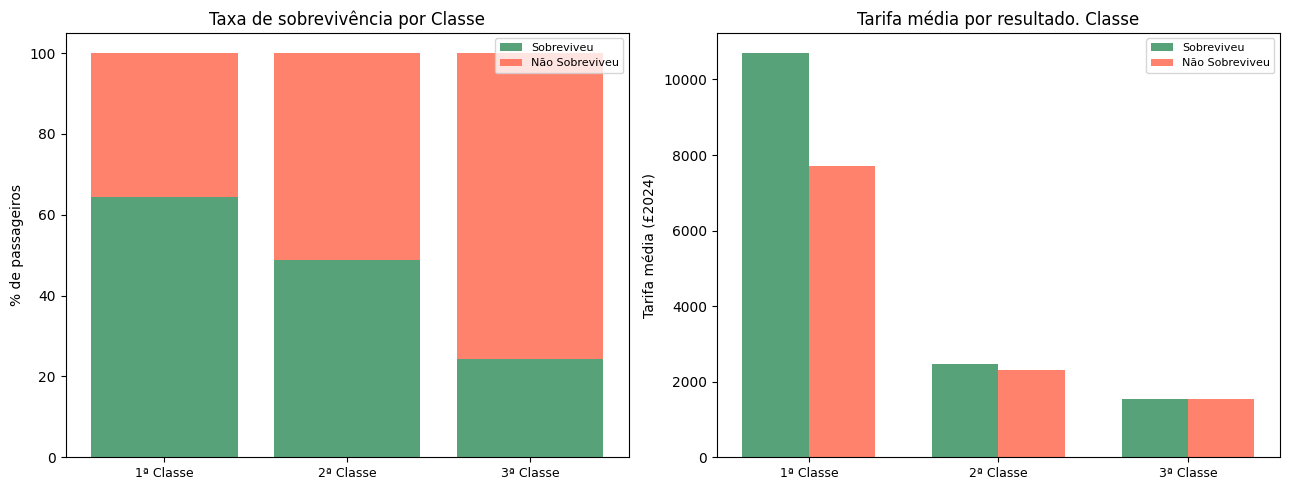

In [20]:
plot_sobrevivencia_por_variavel(
    titanic_df, "Pclass", categorias=[1, 2, 3], titulo="Classe", label_map=LABELS_CLASSE
)

**observações:**
- 1a classe: tarifa mediana maior e taxa de sobrevivência de 64.5%
- 3a classe: tarifa mediana menor e taxa de sobrevivência de 24.4%
- dentro da 1a classe, sobreviventes pagaram tarifas médias acima dos não sobreviventes

#### 3.3.3 Faixa Etária

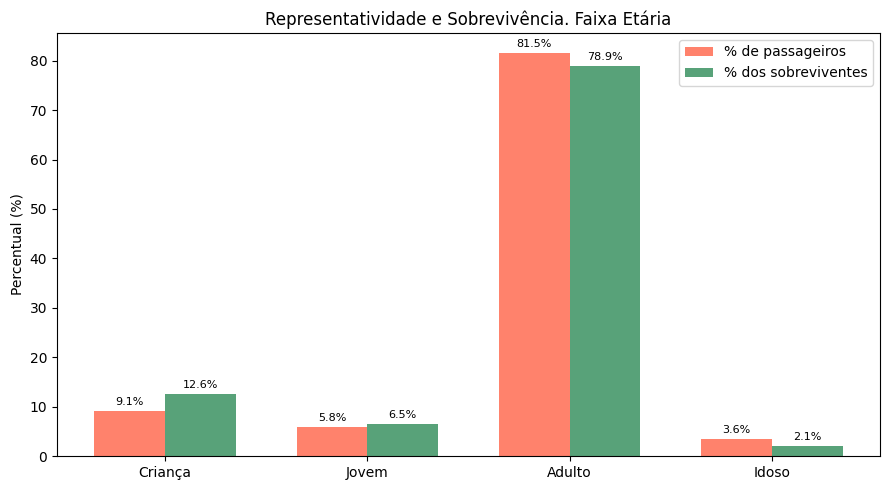

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_representatividade(
    titanic_df,
    "AgeGroup",
    "Representatividade e Sobrevivência. Faixa Etária",
    ax,
    order=["Criança", "Jovem", "Adulto", "Idoso"],
)
plt.tight_layout()
plt.show()

##### Distribuição da Tarifa por Faixa Etária

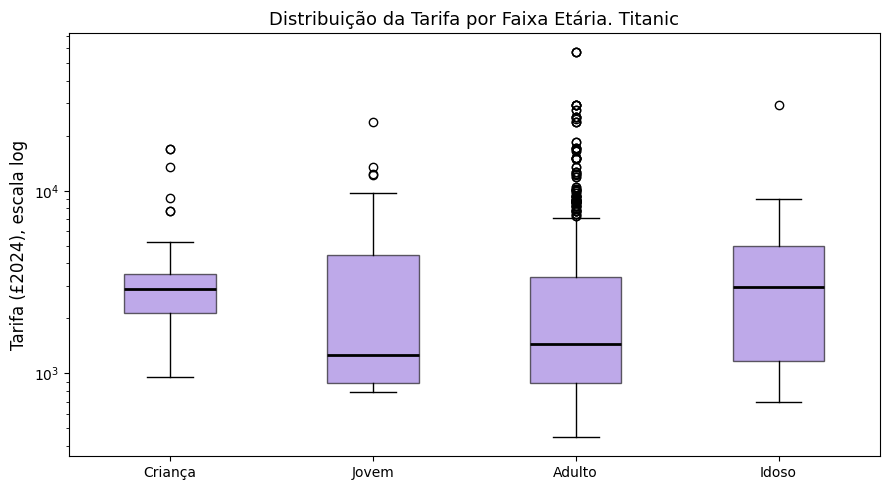

Criança: mediana = £ 2,910 | n = 79
Jovem: mediana = £ 1,258 | n = 51
Adulto: mediana = £ 1,455 | n = 711
Idoso: mediana = £ 2,971 | n = 31


In [22]:
plot_boxplot_tarifa(
    titanic_df,
    "AgeGroup",
    categorias=["Criança", "Jovem", "Adulto", "Idoso"],
    titulo="Faixa Etária",
    cor="mediumpurple",
    figsize=(9, 5),
)

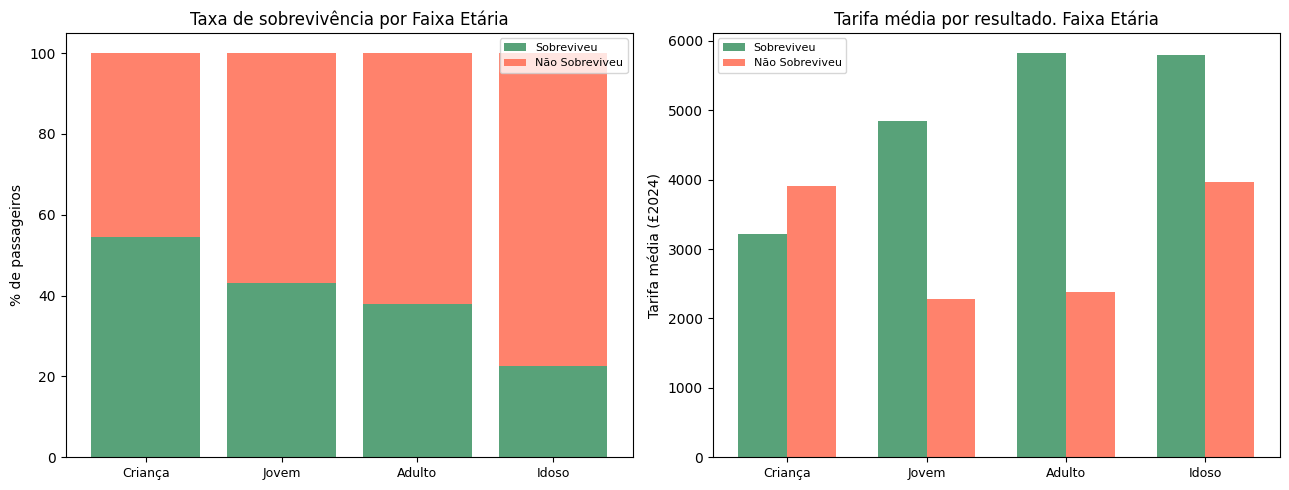

In [23]:
plot_sobrevivencia_por_variavel(
    titanic_df,
    "AgeGroup",
    categorias=["Criança", "Jovem", "Adulto", "Idoso"],
    titulo="Faixa Etária",
)

**observações:**
- crianças: maior taxa de sobrevivência entre as faixas etárias
- adultos: 80% dos passageiros. maior volume absoluto de vítimas
- idosos: menor taxa de sobrevivência entre todas as faixas
- jovens (13-17): grupo pequeno. resultados com menor representatividade

### 3.4 Distribuição e Correlação com Idade

#### 3.4.1 Histograma de Idade

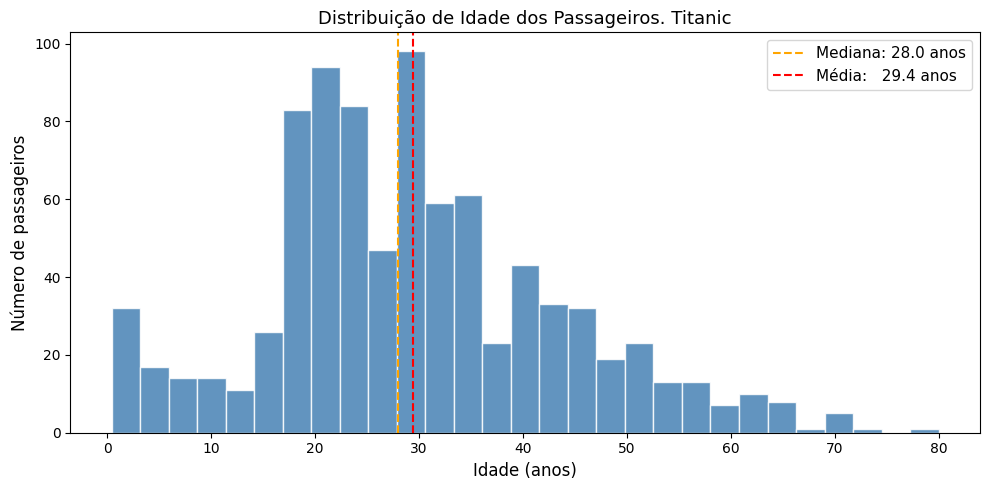

In [24]:
ages = titanic_df["Age"].dropna()
n_bins_age = np.sqrt(len(ages)).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ages, bins=n_bins_age, edgecolor="white", color="steelblue", alpha=0.85)
ax.axvline(
    ages.median(),
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Mediana: {ages.median():.1f} anos",
)
ax.axvline(
    ages.mean(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Média:   {ages.mean():.1f} anos",
)
ax.set_xlabel("Idade (anos)", fontsize=12)
ax.set_ylabel("Número de passageiros", fontsize=12)
ax.set_title("Distribuição de Idade dos Passageiros. Titanic", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**observações:**
- distribuição aproximadamente simétrica: mediana de 28 anos e média de 29.4 anos — valores muito próximos
- concentração entre 20 e 40 anos; presença de crianças e idosos em frequências menores
- baixa assimetria em comparação com a tarifa, cuja razão média/mediana é de 2.3x

**observações:**
- correlação de Pearson r = 0.115: fraca e positiva — praticamente sem relação linear entre idade e tarifa
- p-valor < 0.001 indica significância estatística, mas a magnitude baixa torna a correlação sem relevância prática
- a dispersão no gráfico confirma: passageiros de todas as idades aparecem em toda a amplitude de tarifas

## <font color=blue> 4. Síntese e Conclusões

Nesta seção, reúno as principais medidas descritivas da análise em tabelas resumo para as inferências sobre o perfil dos passageiros e os fatores associados à sobrevivência.

### 4.0 Panorama da Tragédia

Taxa de sobrevivência geral e receita arrecadada com as passagens, incluindo todos os passageiros do dataset (com e sem tarifa). A comparação entre receita por classe e taxa de sobrevivência por classe permite uma leitura crítica sobre a relação entre poder econômico e chance de sobreviver.

In [25]:
# taxa de sobrevivência — dataset completo incluindo Fare = 0
titanic_original = pd.read_csv(PATH_TITANIC)
titanic_original.columns = titanic_original.columns.str.strip()
n_total       = len(titanic_original)
n_sobreviveu  = int(titanic_original["Survived"].sum())
n_nao         = n_total - n_sobreviveu
taxa_geral    = n_sobreviveu / n_total * 100

# receita de bilhetes em £2024 — passageiros pagantes
receita_1912  = titanic_df["Fare"].sum()
receita_2024  = titanic_df["Fare_2024"].sum()
receita_classe = titanic_df.groupby("Pclass").agg(
    receita_2024=("Fare_2024", "sum"),
    n=("Fare_2024", "count"),
    taxa_surv=("Survived", "mean"),
)

print(f"  TAXA DE SOBREVIVÊNCIA  (n total = {n_total})")
print(f"  Sobreviveram:     {n_sobreviveu:>4d} passageiros  ({taxa_geral:.1f}%)")
print(f"  Não sobreviveram: {n_nao:>4d} passageiros  ({100 - taxa_geral:.1f}%)")

print()
print(f"  RECEITA DE BILHETES  (passageiros pagantes, n = {len(titanic_df)})")
print(f"  Total £1912:  £ {receita_1912:>10,.2f}")
print(f"  Total £2024:  £ {receita_2024:>10,.0f}")
print()
for cls in [1, 2, 3]:
    row = receita_classe.loc[cls]
    print(
        f"  {LABELS_CLASSE[cls]}: "
        f"£ {row['receita_2024']:>10,.0f}  "
        f"({row['receita_2024'] / receita_2024 * 100:.1f}% receita | "
        f"{int(row['n'])} pass. | "
        f"sobrevivência: {row['taxa_surv'] * 100:.1f}%)"
    )

  TAXA DE SOBREVIVÊNCIA  (n total = 887)
  Sobreviveram:      342 passageiros  (38.6%)
  Não sobreviveram:  545 passageiros  (61.4%)

  RECEITA DE BILHETES  (passageiros pagantes, n = 872)
  Total £1912:  £  28,654.91
  Total £2024:  £  3,206,783

  1ª Classe: £  2,034,242  (63.4% receita | 211 pass. | sobrevivência: 64.5%)
  2ª Classe: £    425,466  (13.3% receita | 178 pass. | sobrevivência: 48.9%)
  3ª Classe: £    747,075  (23.3% receita | 483 pass. | sobrevivência: 24.4%)


**observações:**
- taxa de sobrevivência geral: **38.6%**. mais de 6 em cada 10 passageiros não sobreviveram
- a 1ª classe gerou a maior parte da receita com menos de 25% dos passageiros e teve a maior taxa de sobrevivência
- a 3ª classe representou mais da metade dos passageiros, contribuiu com a menor fatia da receita e teve taxa de sobrevivência de apenas 24.4%
- o Titanic carregava botes salva-vidas com capacidade para cerca de 53% das pessoas a bordo — dentro da regulação vigente em 1912, baseada na tonelagem da embarcação e não no número de passageiros
- o desastre levou à criação da Convenção SOLAS em 1914 (Safety of Life at Sea), que passou a exigir botes em número suficiente para todos a bordo — uma mudança direta motivada por essa tragédia

### 4.1 Perfil Geral dos Passageiros

Medidas de posição e dispersão da tarifa e da idade para o universo completo de passageiros.

In [26]:
resumo = (
    pd.DataFrame(
        {
            "Tarifa (£1912)": titanic_df["Fare"],
            "Tarifa (£2024)": titanic_df["Fare_2024"],
            "Idade": titanic_df["Age"],
        }
    )
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
)

resumo.columns = ["N", "Média", "Mediana", "Desvio Padrão", "Mínimo", "Máximo"]
resumo.insert(
    6,
    "Assimetria",
    [
        skew(titanic_df["Fare"]),
        skew(titanic_df["Fare_2024"]),
        skew(titanic_df["Age"]),
    ],
)
resumo["Razão Média/Mediana"] = resumo["Média"] / resumo["Mediana"]

display(
    resumo.style.format(
        {
            "N": "{:,.0f}",
            "Média": "{:,.2f}",
            "Mediana": "{:,.2f}",
            "Desvio Padrão": "{:,.2f}",
            "Mínimo": "{:,.2f}",
            "Máximo": "{:,.2f}",
            "Assimetria": "{:.2f}",
            "Razão Média/Mediana": "{:.1f}x",
        }
    ).set_caption("Tabela 4.1, Medidas descritivas de Tarifa e Idade")
)

,N,Média,Mediana,Desvio Padrão,Mínimo,Máximo,Assimetria,Razão Média/Mediana
Tarifa (£1912),872,32.86,14.50,50.03,4.01,512.33,4.75,2.3x
Tarifa (£2024),872,"3,677.50","1,622.70","5,598.48",449.04,"57,334.98",4.75,2.3x
Idade,872,29.43,28.00,14.19,0.42,80.00,0.45,1.1x


**observações:**
- tarifa: assimetria de 4.75. média (£ 3.678) é 2.3x a mediana (£ 1.623)
- idade: mediana de 28 anos e média de 29.5 anos. distribuição mais simétrica

#### 4.1.1 Medidas Separatrizes da Idade

In [27]:
ages_all = titanic_df["Age"].dropna()

quantis = ages_all.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
iqr = quantis[0.75] - quantis[0.25]

resumo_age = pd.DataFrame(
    {
        "Medida": [
            "P10 (10º percentil)",
            "Q1 — 1º quartil (25º percentil)",
            "Q2 — Mediana (50º percentil)",
            "Q3 — 3º quartil (75º percentil)",
            "P90 (90º percentil)",
            "IIQ — Intervalo Interquartil (Q3 − Q1)",
        ],
        "Valor (anos)": [
            quantis[0.10],
            quantis[0.25],
            quantis[0.50],
            quantis[0.75],
            quantis[0.90],
            iqr,
        ],
    }
)

display(
    resumo_age.style
    .format({"Valor (anos)": "{:.1f}"})
    .set_caption("Tabela 4.1.1. Medidas separatrizes da variável Idade")
    .hide(axis="index")
)

Medida,Valor (anos)
P10 (10º percentil),14.1
Q1 — 1º quartil (25º percentil),20.0
Q2 — Mediana (50º percentil),28.0
Q3 — 3º quartil (75º percentil),38.0
P90 (90º percentil),49.0
IIQ — Intervalo Interquartil (Q3 − Q1),18.0


**observações:**
- 50% dos passageiros têm entre 20 e 38 anos (Q1 = 20, Q3 = 38). IIQ = 18 anos
- P10 = 14.1 anos e P90 = 49 anos delimitam os 80% centrais da distribuição
- a proximidade entre Q2 (28 anos) e a média (29.4 anos) confirma a baixa assimetria da variável Idade

### 4.2 Sobrevivência por Grupo

In [28]:
res_df = titanic_df.copy()
res_df["Resultado"] = res_df["Survived"].map({1: "Sobreviveu", 0: "Não Sobreviveu"})

tabela_resultado = (
    res_df.groupby("Resultado")
    .agg(
        N=("Fare", "count"),
        Tarifa_Media=("Fare", "mean"),
        Tarifa_Mediana=("Fare", "median"),
        Tarifa_Media_2024=("Fare_2024", "mean"),
        Tarifa_Mediana_2024=("Fare_2024", "median"),
        Idade_Media=("Age", "mean"),
        Idade_Mediana=("Age", "median"),
    )
    .reindex(["Sobreviveu", "Não Sobreviveu"])
)

tabela_resultado["Taxa (%)"] = (
    tabela_resultado["N"] / tabela_resultado["N"].sum() * 100
).map("{:.1f}%".format)

tabela_resultado.columns = [
    "N",
    "Tarifa Média",
    "Tarifa Mediana",
    "Tarifa Média 2024",
    "Tarifa Mediana 2024",
    "Idade Média",
    "Idade Mediana",
    "Taxa (%)",
]

display(
    tabela_resultado.style.format(
        {
            "N": "{:,.0f}",
            "Tarifa Média": "£ {:,.2f}",
            "Tarifa Mediana": "£ {:,.2f}",
            "Tarifa Média 2024": "£ {:,.0f}",
            "Tarifa Mediana 2024": "£ {:,.0f}",
            "Idade Média": "{:.1f}",
            "Idade Mediana": "{:.1f}",
        }
    ).set_caption("Tabela 4.2, Perfil de Sobreviventes e Não Sobreviventes")
)

,N,Tarifa Média,Tarifa Mediana,Tarifa Média 2024,Tarifa Mediana 2024,Idade Média,Idade Mediana,Taxa (%)
Resultado,,,,,,,,
Sobreviveu,341,£ 48.54,£ 26.00,"£ 5,432","£ 2,910",28.4,28.0,39.1%
Não Sobreviveu,531,£ 22.79,£ 10.50,"£ 2,551","£ 1,175",30.1,28.0,60.9%


**observações:**
- sobreviventes pagaram tarifa média de £ 5.432 vs £ 2.551 dos não sobreviventes. razão de ~2.1x
- tarifa mediana dos sobreviventes também acima. relação consistente com a classe econômica
- idade média dos sobreviventes abaixo da dos não sobreviventes. reflexo da prioridade a crianças

### 4.3 Desigualdades Demográficas na Sobrevivência

In [29]:
def tabela_demografica_titanic(df, coluna, categorias):
    rows = []
    for cat in categorias:
        sub = df[df[coluna] == cat]
        rows.append(
            {
                "Categoria": str(cat),
                "N Passageiros": len(sub),
                "% Passageiros": len(sub) / len(df) * 100,
                "Taxa Sobrevivência (%)": sub["Survived"].mean() * 100,
                "Tarifa Média": sub["Fare"].mean(),
                "Tarifa Mediana": sub["Fare"].median(),
                "Tarifa Média 2024": sub["Fare_2024"].mean(),
                "Tarifa Mediana 2024": sub["Fare_2024"].median(),
                "Idade Média": sub["Age"].mean(),
            }
        )
    return pd.DataFrame(rows).set_index("Categoria")


fmt = {
    "N Passageiros": "{:,.0f}",
    "% Passageiros": "{:.1f}%",
    "Taxa Sobrevivência (%)": "{:.1f}%",
    "Tarifa Média": "£ {:,.2f}",
    "Tarifa Mediana": "£ {:,.2f}",
    "Tarifa Média 2024": "£ {:,.0f}",
    "Tarifa Mediana 2024": "£ {:,.0f}",
    "Idade Média": "{:.1f}",
}

#### 4.3.1 Sexo

In [30]:
tab_sexo = tabela_demografica_titanic(titanic_df, "Sex", ["male", "female"])
display(tab_sexo.style.format(fmt).set_caption("Tabela 4.3.1. Resumo por Sexo"))

,N Passageiros,% Passageiros,Taxa Sobrevivência (%),Tarifa Média,Tarifa Mediana,Tarifa Média 2024,Tarifa Mediana 2024,Idade Média
Categoria,,,,,,,,
male,558,64.0%,19.4%,£ 26.32,£ 12.41,"£ 2,946","£ 1,389",30.4
female,314,36.0%,74.2%,£ 44.48,£ 23.00,"£ 4,978","£ 2,574",27.7


#### 4.3.2 Classe

In [31]:
tab_classe = tabela_demografica_titanic(titanic_df, "Pclass", [1, 2, 3])
display(tab_classe.style.format(fmt).set_caption("Tabela 4.3.2. Resumo por Classe"))

,N Passageiros,% Passageiros,Taxa Sobrevivência (%),Tarifa Média,Tarifa Mediana,Tarifa Média 2024,Tarifa Mediana 2024,Idade Média
Categoria,,,,,,,,
1,211,24.2%,64.5%,£ 86.15,£ 61.98,"£ 9,641","£ 6,936",38.8
2,178,20.4%,48.9%,£ 21.36,£ 15.02,"£ 2,390","£ 1,681",30.0
3,483,55.4%,24.4%,£ 13.82,£ 8.05,"£ 1,547",£ 901,25.1


#### 4.3.3 Faixa Etária

In [32]:
tab_age = tabela_demografica_titanic(
    titanic_df, "AgeGroup", ["Criança", "Jovem", "Adulto", "Idoso"]
)
display(tab_age.style.format(fmt).set_caption("Tabela 4.3.3. Resumo por Faixa Etária"))

,N Passageiros,% Passageiros,Taxa Sobrevivência (%),Tarifa Média,Tarifa Mediana,Tarifa Média 2024,Tarifa Mediana 2024,Idade Média
Categoria,,,,,,,,
Criança,79,9.1%,54.4%,£ 31.56,£ 26.00,"£ 3,532","£ 2,910",4.9
Jovem,51,5.8%,43.1%,£ 30.28,£ 11.24,"£ 3,389","£ 1,258",15.8
Adulto,711,81.5%,37.8%,£ 32.92,£ 13.00,"£ 3,684","£ 1,455",31.6
Idoso,31,3.6%,22.6%,£ 39.17,£ 26.55,"£ 4,384","£ 2,971",65.0


### 4.4 Conclusões

**conclusões:**
- taxa de sobrevivência geral: **38.6%** — mais de 6 em cada 10 passageiros não sobreviveram
- sexo: mulheres com 74.2% de sobrevivência vs 19.4% dos homens. diferença de 54.8 p.p. maior gap entre todas as variáveis
- classe: 1a classe com 64.5% vs 24.4% da 3a classe. diferença de 40.0 p.p. tarifa média dos sobreviventes foi ~2.1x a dos não sobreviventes
- receita: a 1a classe gerou a maior parte da receita com menos de 25% dos passageiros e teve a maior sobrevivência. a 3a classe pagou menos, representou mais da metade dos passageiros e teve a pior taxa de sobrevivência
- faixa etária: crianças com maior taxa relativa. idosos com menor. adultos representam 81.5% do total e o maior volume absoluto de vítimas
- impacto regulatório: o desastre levou à criação da Convenção SOLAS em 1914, que passou a exigir botes salva-vidas suficientes para todos a bordo — antes disso, a regulação era baseada na tonelagem da embarcação, não no número de pessoas